In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile

with zipfile.ZipFile('/content/FER-2013 (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [ ]:
import subprocess

# Run the 'file' command to check the file type
result = subprocess.run(['file', '/content/FER-2013 (2).zip'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

/content/FER-2013 (2).zip: Zip archive data, at least v4.5 to extract, compression method=deflate




In [ ]:
import os
os.listdir('/content')

['.config',
 'train',
 '.ipynb_checkpoints',
 'FER-2013 (2).zip',
 'test',
 'sample_data']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255)


In [ ]:
train_data=train_datagen.flow_from_directory(
    '/content/train',
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical')

Found 28709 images belonging to 7 classes.


In [ ]:
test_data=test_datagen.flow_from_directory(
    '/content/test',
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical')

Found 7178 images belonging to 7 classes.


In [ ]:
print(train_data.samples)
print(test_data.samples)

28709
7178


In [ ]:
print(train_data.class_mode)
print(test_data.class_mode)

categorical
categorical


In [ ]:
print(train_data.class_indices)
print(train_data.image_shape)
print(test_data.class_indices)
print(test_data.image_shape)

{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
(48, 48, 1)
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
(48, 48, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
model=Sequential()
model.add(Conv2D(32,(3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels=train_data.classes
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights=dict(enumerate(class_weights))

In [ ]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=25,
    class_weight=class_weights)

Epoch 1/25


KeyboardInterrupt: 

In [ ]:
model.save("fer_emotion_model.keras")

NameError: name 'model' is not defined

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"],label="train accuracy")
plt.plot(history.history["val_accuracy"],label="val accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()
plt.plot(history.history["loss"],label="train loss")
plt.plot(history.history["val_loss"],label="val loss")
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
model=Sequential()
model.add(Conv2D(32,(3,3), padding='same', activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(64,(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Conv2D(128,(3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(7, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels=train_data.classes
class_weights=compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights=dict(enumerate(class_weights))

In [ ]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=25,
    callbacks=[early_stop])

Epoch 1/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.5420 - loss: 1.2199 - val_accuracy: 0.5380 - val_loss: 1.2054
Epoch 2/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.5467 - loss: 1.2116 - val_accuracy: 0.5254 - val_loss: 1.2957
Epoch 3/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.5467 - loss: 1.2077 - val_accuracy: 0.5644 - val_loss: 1.1566
Epoch 4/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.5535 - loss: 1.1953 - val_accuracy: 0.5571 - val_loss: 1.1683
Epoch 5/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.5540 - loss: 1.1929 - val_accuracy: 0.5598 - val_loss: 1.1815
Epoch 6/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.5586 - loss: 1.1775 - val_accuracy: 0.5763 - val_loss: 1.1358
Epoch 7/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.5541 - loss: 1.1869 - val_accuracy: 0.5656 - val_loss: 1.1816
Epoch 8/25
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.5589 - loss: 1.1705 - 

In [ ]:
print(train_data.class_indices)

print(test_data.class_indices)

print(class_weights)


{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,920,919 (14.96 MB)

 Trainable params: 1,306,823 (4.99 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2,613,648 (9.97 MB)

In [ ]:
model.save("fer_emotion_model.keras")


In [ ]:
from google.colab import files
files.download('fer_emotion_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
face_model = load_model('/content/fer_emotion_model.keras')

In [ ]:
uploaded=files.upload()

Saving PrivateTest_366361.jpg to PrivateTest_366361.jpg


In [ ]:
uploaded=files.upload()


Saving PrivateTest_95094.jpg to PrivateTest_95094 (1).jpg


In [ ]:
import cv2
img=cv2.imread('/content/PrivateTest_95094.jpg',cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(48,48))
img=img/255.0
img=img.reshape(1,48,48,1)


In [ ]:
prediction=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


In [ ]:
print(prediction)

[[0.07151068 0.00322145 0.04568093 0.46472222 0.32198367 0.0795548
  0.01332632]]


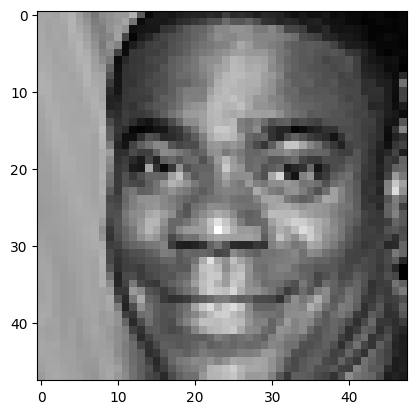

In [ ]:
img=img.reshape(48,48)
import matplotlib.pyplot as plt
plt.imshow(img,cmap='gray')
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


<Figure size 800x800 with 0 Axes>

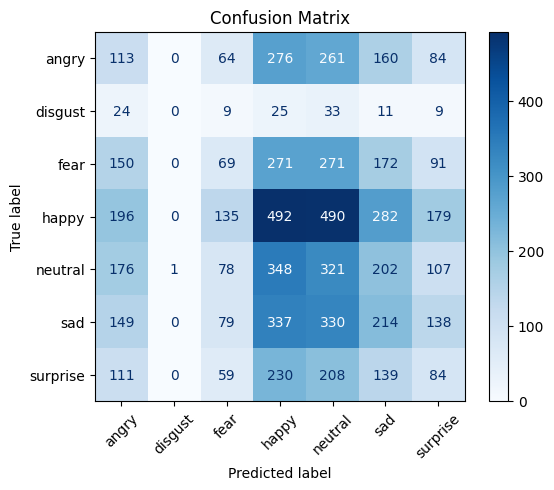

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
test_data.reset()
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
cm = confusion_matrix(y_true, y_pred_classes)
class_names = list(test_data.class_indices.keys())
plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

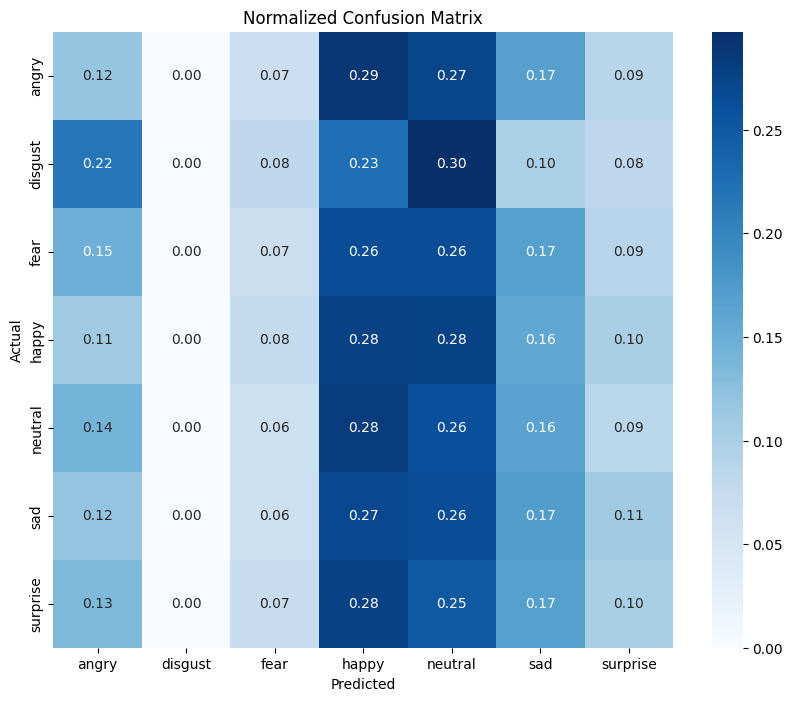

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


cm = confusion_matrix(y_true, y_pred_classes)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")
plt.show()